# MindTrack — Auditoría de Calidad, EDA Profundo y Pipeline de Limpieza

#### Valentina Ramirez - Nicoll Quesada

### Unidad 2: Recolección, depuración e integración de datos
### Universidad de La Sabana — Ciencia de Datos

**Proyecto:** Sistema de apoyo para la identificación temprana del riesgo de depresión en
estudiantes universitarios mediante Ciencia de Datos.

**Equipo:** Nicoll (liderazgo técnico) y Valentina (liderazgo de gestión)

**Fuente principal:** Student Depression Dataset (Kaggle, ~27.900 registros de estudiantes en India)
**Fuente complementaria:** Encuesta Nacional de Salud Mental (ENSM) — Ministerio de Salud y
Protección Social de Colombia (usada para contextualizar, no para entrenar el modelo)

---

## Estructura de este notebook

Este notebook sigue, sin saltarse ningún paso, los 4 pasos que exige la guía de actividad de la
Unidad 2 (*Taller Práctico de Limpieza e Integración de Datos*):

| Paso de la guía | Sección de este notebook |
|---|---|
| Paso 1 — Auditoría de calidad (completitud, consistencia, trazabilidad) | Secciones 2 y 3 |
| Paso 2 — Transformaciones de limpieza e integración, documentadas | Secciones 4 y 5 |
| Paso 3 — Control de versiones en Git | Sección 6 (documentación del commit) |
| Paso 4 — Preparación para revisión del docente | Sección 7 (resumen ejecutable) |

Adicionalmente se incluye un **Análisis Exploratorio de Datos (EDA) profundo** (Sección 3) y una
**auditoría preliminar de sesgo** (Sección 5.7), que sirven como insumo directo para la
**Bitácora de Error #2**.


## 0. Configuración del entorno

Esta celda instala (si hace falta) y carga todas las librerías necesarias. Está pensada para
correr sin modificaciones en Jupyter local, JupyterLab, Google Colab o VSCode.


In [ ]:
# Descomentar la siguiente línea solo si falta alguna librería en el entorno
# !pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### 0.1 Carga portable del dataset

Esta celda busca el archivo `Student_Depression_Dataset.csv` en varias ubicaciones posibles,
para que el notebook funcione sin importar si lo corren desde la carpeta `notebooks/` del
repositorio, desde la raíz del proyecto, o desde Google Colab. Si no lo encuentra en ninguna
ruta conocida, se les pide indicarlo manualmente.


In [ ]:
from google.colab import files
import pandas as pd

# Subir el archivo desde tu computador
archivos = files.upload()

# Obtener el nombre del archivo subido
nombre_archivo = next(iter(archivos))

# Leer el dataset
df = pd.read_csv(nombre_archivo)

print(f"Dataset encontrado en: {nombre_archivo}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Saving Student Depression Dataset.csv to Student Depression Dataset.csv
Dataset encontrado en: Student Depression Dataset.csv
Filas: 27,901 | Columnas: 18


### 0.2 Vista inicial del dataset

In [ ]:
df.head(10)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,Less than 5 hours,Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,7-8 hours,Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,Less than 5 hours,Unhealthy,Class 12,No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,7-8 hours,Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,Less than 5 hours,Moderate,LLB,Yes,2.0,5.0,No,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,27901.0,NaN,NaN,NaN,70442.149421,40641.175216,2.0,35039.0,70684.0,105818.0,140699.0
Gender,27901,2,Male,15547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,27901.0,NaN,NaN,NaN,25.8223,4.905687,18.0,21.0,25.0,30.0,59.0
City,27901,52,Kalyan,1570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,27901,14,Student,27870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic Pressure,27901.0,NaN,NaN,NaN,3.141214,1.381465,0.0,2.0,3.0,4.0,5.0
Work Pressure,27901.0,NaN,NaN,NaN,0.00043,0.043992,0.0,0.0,0.0,0.0,5.0
CGPA,27901.0,NaN,NaN,NaN,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,NaN,NaN,NaN,2.943837,1.361148,0.0,2.0,3.0,4.0,5.0
Job Satisfaction,27901.0,NaN,NaN,NaN,0.000681,0.044394,0.0,0.0,0.0,0.0,4.0


## 1. Contexto y alcance del análisis

Antes de tocar los datos, dejamos explícito qué es cada fuente y qué rol cumple:

- **Student Depression Dataset**: fuente principal, a nivel de estudiante individual. Se usará
  para entrenar y evaluar el modelo de clasificación.
- **ENSM (Colombia)**: fuente complementaria, a nivel agregado/nacional. No se integra fila por
  fila con el dataset principal (son poblaciones distintas); se usa para **contrastar
  prevalencias y contextualizar** los resultados del modelo desde la realidad colombiana en la
  fase de interpretación, no en esta fase de limpieza.

**Advertencia de origen:** el dataset principal corresponde a estudiantes de **India**, no de
Colombia ni Latinoamérica. Esto se documenta aquí porque es central para la auditoría de sesgo
de la Sección 5.7 y para la Bitácora de Error #2.


## 2. Auditoría de calidad de datos (Paso 1 de la guía)

Aplicamos las 3 dimensiones que exige la guía de estudio de la Unidad 2: **completitud**,
**consistencia** y **trazabilidad**. Este diagnóstico se hace *antes* de intervenir los datos,
y es en sí mismo el primer entregable técnico del pipeline.


### 2.1 Completitud — ¿qué porcentaje de valores está presente por variable?

In [ ]:
completitud = pd.DataFrame({
    'valores_presentes': df.notna().sum(),
    'valores_faltantes': df.isna().sum(),
    '% completitud': (df.notna().mean() * 100).round(2),
    '% faltantes': (df.isna().mean() * 100).round(2),
}).sort_values('% faltantes', ascending=False)

completitud


,valores_presentes,valores_faltantes,% completitud,% faltantes
Financial Stress,27898,3,99.99,0.01
id,27901,0,100.00,0.00
Gender,27901,0,100.00,0.00
Age,27901,0,100.00,0.00
Profession,27901,0,100.00,0.00
City,27901,0,100.00,0.00
Work Pressure,27901,0,100.00,0.00
CGPA,27901,0,100.00,0.00
Study Satisfaction,27901,0,100.00,0.00
Academic Pressure,27901,0,100.00,0.00


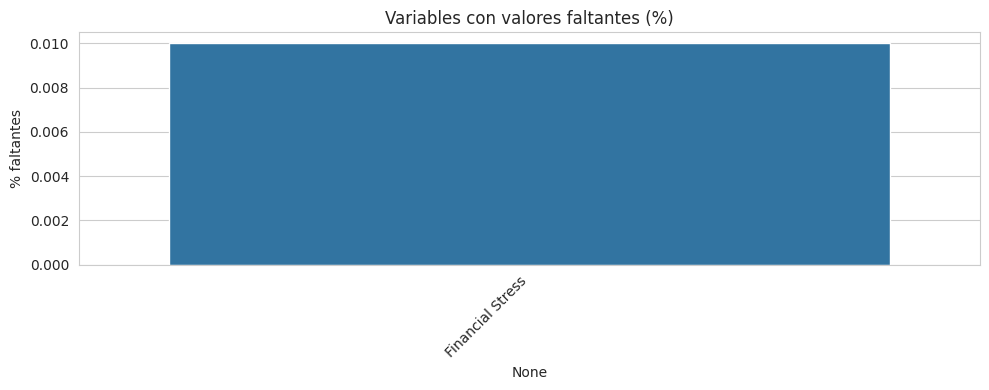

In [ ]:
plt.figure(figsize=(10, 4))
completitud_con_faltantes = completitud[completitud['% faltantes'] > 0]
if len(completitud_con_faltantes) > 0:
    sns.barplot(x=completitud_con_faltantes.index, y=completitud_con_faltantes['% faltantes'])
    plt.title('Variables con valores faltantes (%)')
    plt.ylabel('% faltantes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No hay variables con valores faltantes por encima de 0%.")


**Hallazgo de completitud:** la única variable con valores faltantes es `Financial Stress`.
El resto del dataset está 100% completo. El porcentaje de faltantes en `Financial Stress` es muy
bajo — lo cuantificamos abajo antes de decidir cómo tratarlo.

In [ ]:
n_faltantes_fs = df['Financial Stress'].isna().sum()
pct_faltantes_fs = df['Financial Stress'].isna().mean() * 100
print(f"Financial Stress: {n_faltantes_fs} registros faltantes ({pct_faltantes_fs:.4f}% del total)")


Financial Stress: 3 registros faltantes (0.0108% del total)


### 2.2 Consistencia — ¿las categorías están codificadas de forma coherente en toda la fuente?

In [ ]:
columnas_categoricas = df.select_dtypes(include='object').columns.tolist()
print("Variables categóricas detectadas:", columnas_categoricas)


Variables categóricas detectadas: ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [ ]:
for col in columnas_categoricas:
    n_unicos = df[col].nunique()
    print(f"\n--- {col} ({n_unicos} categorías únicas) ---")
    if n_unicos <= 15:
        print(df[col].value_counts())
    else:
        print(f"(alta cardinalidad, mostrando las 10 más frecuentes)")
        print(df[col].value_counts().head(10))



--- Gender (2 categorías únicas) ---
Gender
Male      15547
Female    12354
Name: count, dtype: int64

--- City (52 categorías únicas) ---
(alta cardinalidad, mostrando las 10 más frecuentes)
City
Kalyan         1570
Srinagar       1372
Hyderabad      1340
Vasai-Virar    1290
Lucknow        1155
Thane          1139
Ludhiana       1111
Agra           1094
Surat          1078
Kolkata        1066
Name: count, dtype: int64

--- Profession (14 categorías únicas) ---
Profession
Student                   27870
Architect                     8
Teacher                       6
Digital Marketer              3
Chef                          2
Content Writer                2
Pharmacist                    2
Doctor                        2
UX/UI Designer                1
Civil Engineer                1
Manager                       1
Educational Consultant        1
Lawyer                        1
Entrepreneur                  1
Name: count, dtype: int64

--- Sleep Duration (5 categorías únicas) ---
Sl

**Hallazgo de consistencia:**
- `Gender`, `Have you ever had suicidal thoughts ?`, `Family History of Mental Illness` tienen
  exactamente 2 categorías cada una, sin variantes de escritura (no hay mezcla de "Yes"/"yes"/"Y").
- `Sleep Duration` tiene 4 categorías claras de rango horario **más una quinta categoría
  ambigua, `"Others"` (18 registros)**, que no encaja en la escala ordinal — se documenta aquí y
  se resuelve explícitamente en la Sección 4.3, como ejemplo real de por qué la auditoría de
  consistencia debe revisar el listado completo de categorías, no solo las más frecuentes.
- `Dietary Habits` tiene categorías consistentes en formato, sin unidades mixtas ni duplicados
  por mayúsculas/minúsculas.
- `City` y `Degree` tienen **alta cardinalidad** (muchas categorías distintas), lo cual no es una
  inconsistencia en sí, pero requiere tratamiento especial en la fase de codificación (Sección 4.5).


### 2.3 Trazabilidad — origen, unicidad de registros y variables de baja utilidad analítica

In [ ]:
# Verificación de identificador único
print(f"Valores únicos en 'id': {df['id'].nunique()} de {len(df)} filas")
print(f"¿El id es único por fila? {df['id'].nunique() == len(df)}")


Valores únicos en 'id': 27901 de 27901 filas
¿El id es único por fila? True


In [ ]:
# Duplicados exactos (todas las columnas iguales)
n_duplicados = df.duplicated().sum()
print(f"Registros completamente duplicados: {n_duplicados}")

# Duplicados por id (ignorando el resto de columnas)
n_duplicados_id = df.duplicated(subset='id').sum()
print(f"Duplicados por 'id': {n_duplicados_id}")


Registros completamente duplicados: 0
Duplicados por 'id': 0


In [ ]:
print("--- Profession ---")
print(df['Profession'].value_counts().head())
pct_student = (df['Profession'] == 'Student').mean() * 100
print(f"\n% de registros con Profession = 'Student': {pct_student:.2f}%")


--- Profession ---
Profession
Student             27870
Architect               8
Teacher                 6
Digital Marketer        3
Chef                    2
Name: count, dtype: int64

% de registros con Profession = 'Student': 99.89%


**Hallazgo de trazabilidad:**
- `id` es único por fila — confirma que cada registro corresponde a un estudiante distinto y que
  no hay duplicación de identidad.
- No se encontraron registros completamente duplicados en esta versión del dataset (se valida de
  nuevo formalmente en la Sección 4.1, ya como parte del pipeline de limpieza).
- `Profession` tiene varianza casi nula: prácticamente todos los registros son "Student". Se
  documenta como variable de **baja utilidad analítica**, pero la decisión de excluirla se toma
  explícitamente en la fase de modelado (no se elimina todavía, para no perder trazabilidad de
  por qué se descartó).


### 2.4 Reporte de calidad consolidado (resumen final del Paso 1)

In [ ]:
reporte_calidad = pd.DataFrame({
    'tipo_dato': df.dtypes.astype(str),
    '% faltantes': (df.isna().mean() * 100).round(2),
    'valores_unicos': df.nunique(),
    'ejemplo_valor': df.iloc[0],
})
reporte_calidad


,tipo_dato,% faltantes,valores_unicos,ejemplo_valor
id,int64,0.00,27901,2
Gender,object,0.00,2,Male
Age,float64,0.00,34,33.0
City,object,0.00,52,Visakhapatnam
Profession,object,0.00,14,Student
Academic Pressure,float64,0.00,6,5.0
Work Pressure,float64,0.00,3,0.0
CGPA,float64,0.00,332,8.97
Study Satisfaction,float64,0.00,6,2.0
Job Satisfaction,float64,0.00,5,0.0


## 3. Análisis Exploratorio de Datos (EDA) profundo

Con el diagnóstico de calidad ya hecho, exploramos la estructura y las relaciones dentro de los
datos, antes de decidir cómo transformarlos.


### 3.1 Variable objetivo: `Depression`

Depression
1    16336
0    11565
Name: count, dtype: int64

Depression
1    58.55
0    41.45
Name: proportion, dtype: float64


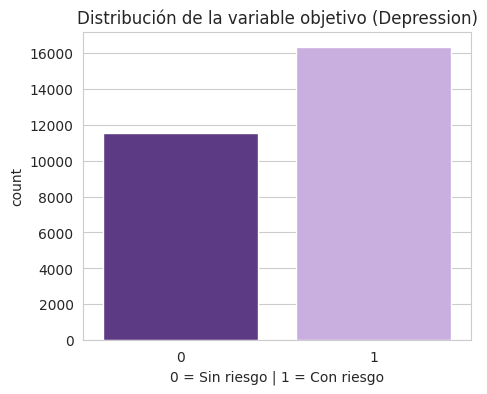

In [ ]:
conteo_target = df['Depression'].value_counts()
pct_target = df['Depression'].value_counts(normalize=True) * 100

print(conteo_target)
print()
print(pct_target.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x='Depression', data=df, hue='Depression', palette=['#5C2D91', '#C9A6E8'], legend=False)
plt.title('Distribución de la variable objetivo (Depression)')
plt.xlabel('0 = Sin riesgo | 1 = Con riesgo')
plt.show()


**Hallazgo:** la variable objetivo está razonablemente balanceada (~58-59% con riesgo de
depresión, ~41-42% sin él). Esto es favorable para el modelado: no se requieren técnicas de
balanceo de clases (SMOTE, undersampling) como paso obligatorio inicial.

### 3.2 Análisis univariado — variables numéricas

In [ ]:
variables_numericas = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                        'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
                        'Financial Stress']

df[variables_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,27901.0,25.822300,4.905687,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141214,1.381465,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000430,0.043992,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.943837,1.361148,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.000681,0.044394,0.0,0.00,0.00,0.00,4.0
Work/Study Hours,27901.0,7.156984,3.707642,0.0,4.00,8.00,10.00,12.0
Financial Stress,27898.0,3.139867,1.437347,1.0,2.00,3.00,4.00,5.0


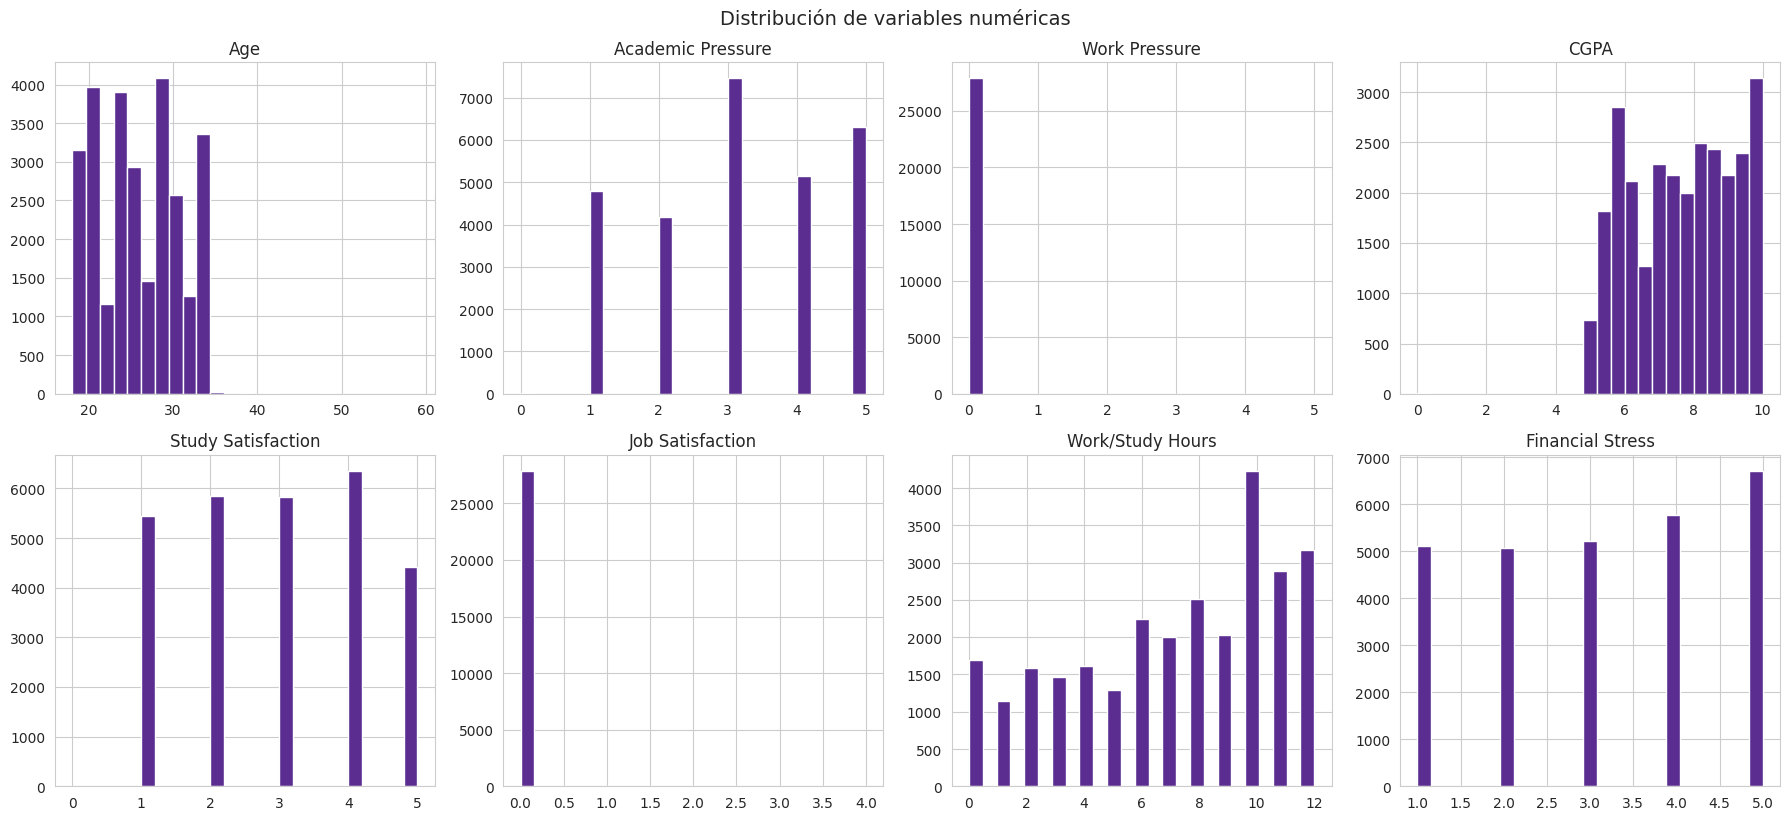

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(variables_numericas):
    df[col].hist(bins=25, ax=axes[i], color='#5C2D91', edgecolor='white')
    axes[i].set_title(col)
plt.tight_layout()
plt.suptitle('Distribución de variables numéricas', y=1.02, fontsize=14)
plt.show()


### 3.3 Detección de outliers (método IQR)

Se aplica el método del rango intercuartílico a las variables numéricas continuas, **antes** de
cualquier normalización, para no enmascarar valores atípicos (punto crítico señalado en la guía
de estudio de la unidad).

In [ ]:
def resumen_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    return {
        'Q1': round(q1, 2), 'Q3': round(q3, 2), 'IQR': round(iqr, 2),
        'límite_inferior': round(lim_inf, 2), 'límite_superior': round(lim_sup, 2),
        'n_outliers': len(outliers), '% outliers': round(len(outliers) / len(serie) * 100, 2),
    }

resumen_outliers = pd.DataFrame({
    col: resumen_outliers_iqr(df[col]) for col in ['Age', 'CGPA', 'Work/Study Hours']
}).T
resumen_outliers


,Q1,Q3,IQR,límite_inferior,límite_superior,n_outliers,% outliers
Age,21.00,30.00,9.00,7.50,43.50,12.0,0.04
CGPA,6.29,8.92,2.63,2.35,12.86,9.0,0.03
Work/Study Hours,4.00,10.00,6.00,-5.00,19.00,0.0,0.00


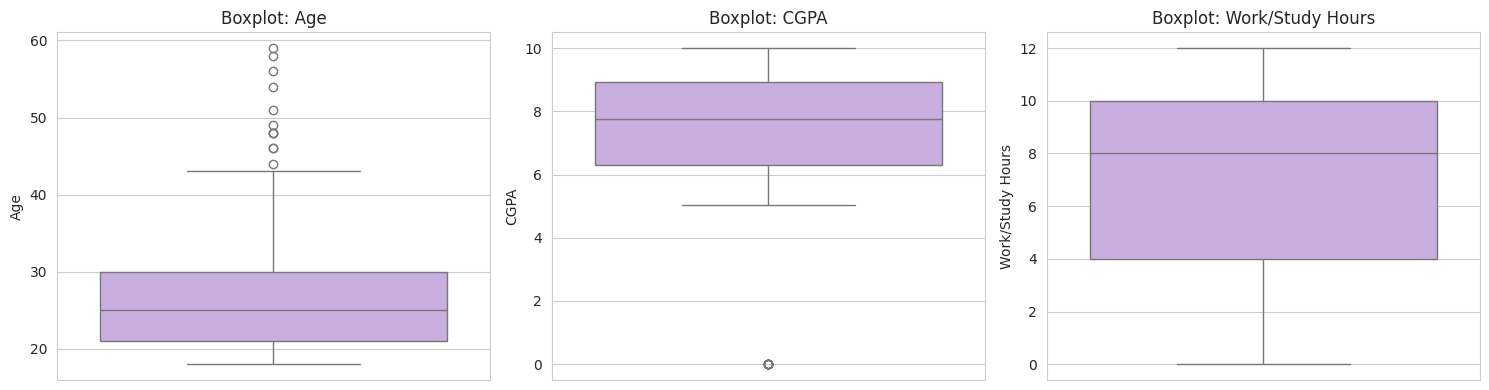

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Age', 'CGPA', 'Work/Study Hours']):
    sns.boxplot(y=df[col], ax=axes[i], color='#C9A6E8')
    axes[i].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()


### 3.4 Análisis univariado — variables categóricas y ordinales

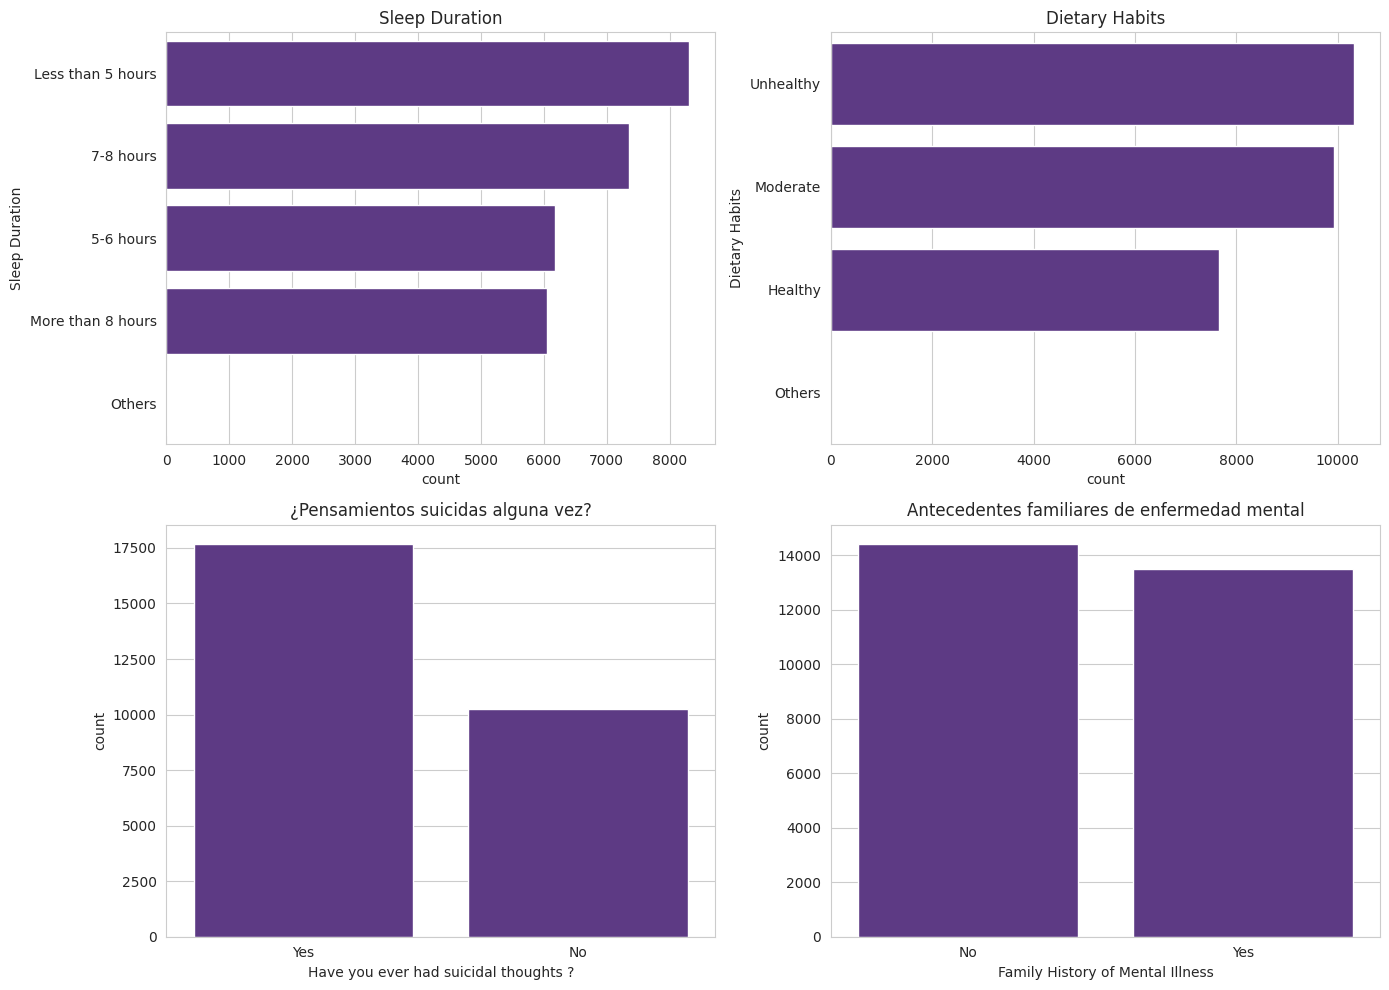

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(y='Sleep Duration', data=df, ax=axes[0,0], color='#5C2D91',
              order=df['Sleep Duration'].value_counts().index)
axes[0,0].set_title('Sleep Duration')

sns.countplot(y='Dietary Habits', data=df, ax=axes[0,1], color='#5C2D91',
              order=df['Dietary Habits'].value_counts().index)
axes[0,1].set_title('Dietary Habits')

sns.countplot(x='Have you ever had suicidal thoughts ?', data=df, ax=axes[1,0], color='#5C2D91')
axes[1,0].set_title('¿Pensamientos suicidas alguna vez?')

sns.countplot(x='Family History of Mental Illness', data=df, ax=axes[1,1], color='#5C2D91')
axes[1,1].set_title('Antecedentes familiares de enfermedad mental')

plt.tight_layout()
plt.show()


### 3.5 Análisis de alta cardinalidad — `City` y `Degree`

In [ ]:
print(f"Ciudades únicas: {df['City'].nunique()}")
print(df['City'].value_counts().head(10))
print(f"\nProgramas académicos únicos: {df['Degree'].nunique()}")
print(df['Degree'].value_counts().head(10))


Ciudades únicas: 52
City
Kalyan         1570
Srinagar       1372
Hyderabad      1340
Vasai-Virar    1290
Lucknow        1155
Thane          1139
Ludhiana       1111
Agra           1094
Surat          1078
Kolkata        1066
Name: count, dtype: int64

Programas académicos únicos: 28
Degree
Class 12    6080
B.Ed        1867
B.Com       1506
B.Arch      1478
BCA         1433
MSc         1190
B.Tech      1152
MCA         1044
M.Tech      1022
BHM          925
Name: count, dtype: int64


**Hallazgo:** ambas variables tienen alta cardinalidad. Ninguna categoría domina de forma
abrumadora (a diferencia de `Profession`), por lo que se marcan para **agrupación o codificación
por frecuencia** en la fase de feature engineering, no para exclusión.

### 3.6 Análisis bivariado — variables vs. `Depression`

Esta es la sección más relevante para responder la pregunta analítica central del proyecto: ¿qué
variables muestran mayor relación con el riesgo de depresión?

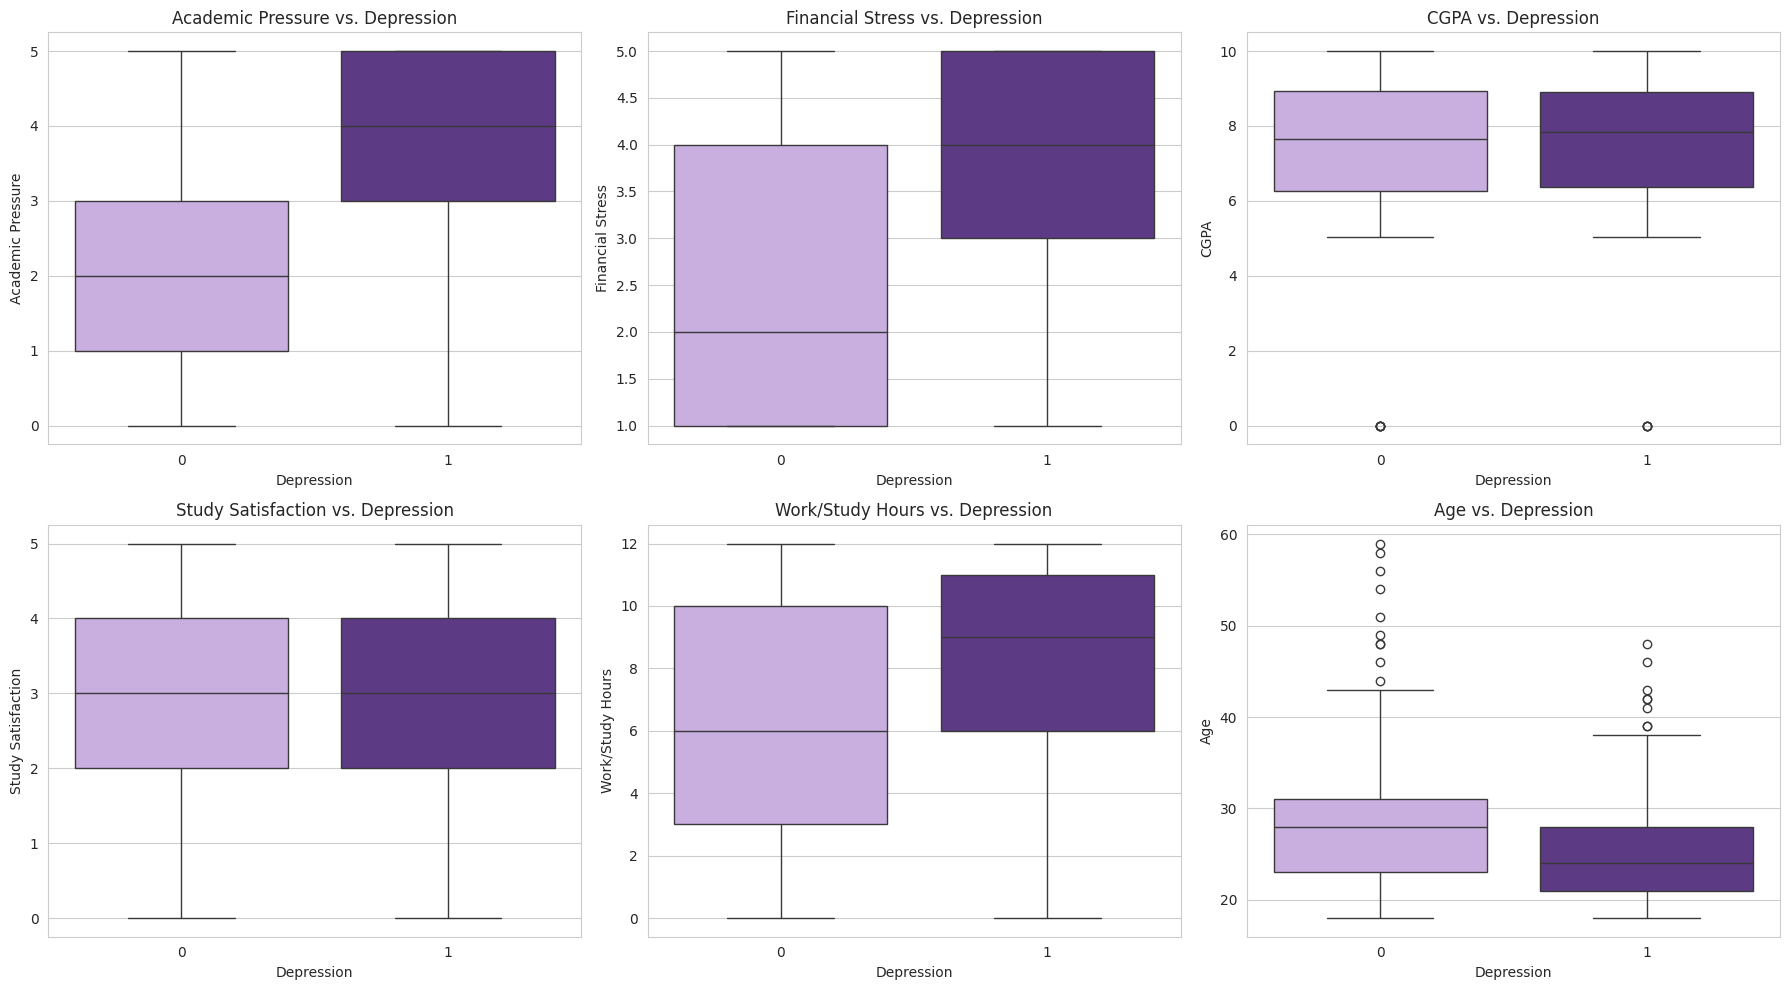

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
vars_bivariado = ['Academic Pressure', 'Financial Stress', 'CGPA',
                   'Study Satisfaction', 'Work/Study Hours', 'Age']
for i, col in enumerate(vars_bivariado):
    ax = axes[i // 3, i % 3]
    sns.boxplot(x='Depression', y=col, data=df, ax=ax, hue='Depression',
                palette=['#C9A6E8', '#5C2D91'], legend=False)
    ax.set_title(f'{col} vs. Depression')
plt.tight_layout()
plt.show()


In [ ]:
# Tasa de depresión por variables categóricas clave
for col in ['Have you ever had suicidal thoughts ?', 'Family History of Mental Illness', 'Gender']:
    print(f"--- Tasa de Depression=1 por categoría de '{col}' ---")
    print(df.groupby(col)['Depression'].mean().round(3) * 100)
    print()


--- Tasa de Depression=1 por categoría de 'Have you ever had suicidal thoughts ?' ---
Have you ever had suicidal thoughts ?
No     23.2
Yes    79.0
Name: Depression, dtype: float64

--- Tasa de Depression=1 por categoría de 'Family History of Mental Illness' ---
Family History of Mental Illness
No     56.0
Yes    61.3
Name: Depression, dtype: float64

--- Tasa de Depression=1 por categoría de 'Gender' ---
Gender
Female    58.5
Male      58.6
Name: Depression, dtype: float64



### 3.7 Matriz de correlación (variables numéricas)

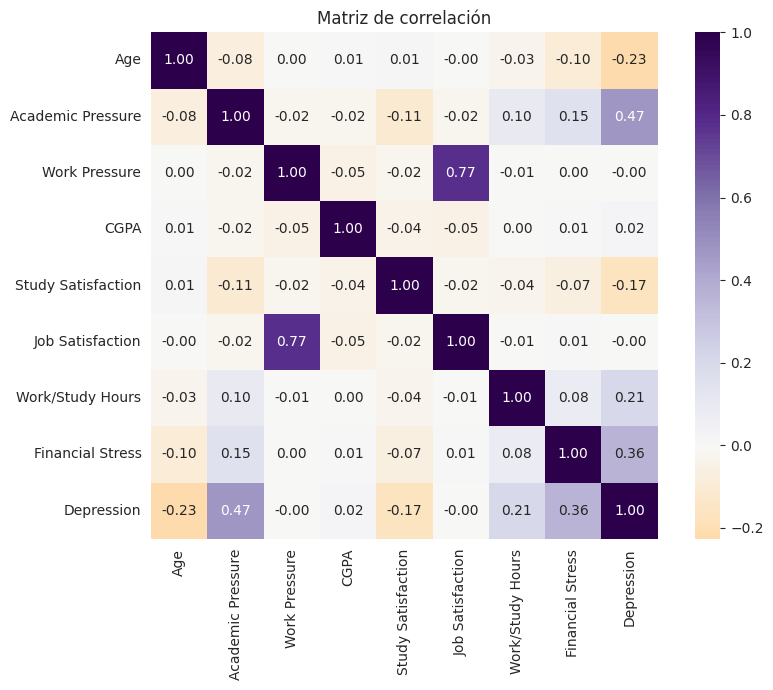

In [ ]:
variables_para_corr = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                        'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
                        'Financial Stress', 'Depression']

matriz_corr = df[variables_para_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='PuOr', center=0, square=True)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()


In [ ]:
correlacion_con_target = matriz_corr['Depression'].sort_values(ascending=False)
print("Correlación de cada variable numérica con Depression, ordenada:")
correlacion_con_target


Correlación de cada variable numérica con Depression, ordenada:


,Depression
Depression,1.000000
Academic Pressure,0.474835
Financial Stress,0.363591
Work/Study Hours,0.208563
CGPA,0.022210
Work Pressure,-0.003351
Job Satisfaction,-0.003482
Study Satisfaction,-0.167971
Age,-0.226422


### 3.8 Hallazgos clave del EDA (resumen)

1. La variable objetivo está razonablemente balanceada — no requiere balanceo de clases obligatorio.
2. `Academic Pressure` y `Financial Stress` muestran la mayor asociación positiva con `Depression`
   entre las variables numéricas — candidatas fuertes para el modelo.
3. `Have you ever had suicidal thoughts ?` muestra una diferencia muy marcada en la tasa de
   depresión entre categorías — variable de altísimo poder predictivo, pero también la más
   sensible desde el punto de vista ético (ver Sección 5.7 y la reflexión ética del Entregable 1).
4. `Profession` no aporta señal (varianza casi nula). `City` y `Degree` tienen alta cardinalidad
   y requieren tratamiento especial antes de poder usarse en un modelo.
5. Los outliers detectados en variables numéricas son pocos y no lucen como errores de captura,
   sino como valores extremos plausibles (se documenta la decisión de conservarlos en la
   Sección 4.6).


## 4. Transformaciones de limpieza e integración (Paso 2 de la guía)

Cada transformación se documenta con su justificación técnica y el supuesto que asumimos, tal
como exige la guía: *"no basta con imputar la media y seguir adelante: hay que explicar por qué
se tomó esa decisión y no otra"*.

A partir de aquí trabajamos sobre una copia del dataset original, para mantener `df` intacto como
referencia.


In [ ]:
df_clean = df.copy()
print(f"Copia de trabajo creada. Shape inicial: {df_clean.shape}")


Copia de trabajo creada. Shape inicial: (27901, 18)


### 4.1 Eliminación de duplicados

**Decisión:** eliminar registros completamente duplicados. **Supuesto:** un duplicado exacto
representa un error de carga, no una coincidencia real entre dos estudiantes distintos.

In [ ]:
n_antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
n_despues = len(df_clean)
print(f"Filas antes: {n_antes} | después: {n_despues} | eliminadas: {n_antes - n_despues}")


Filas antes: 27901 | después: 27901 | eliminadas: 0


### 4.2 Tratamiento de valores faltantes en `Financial Stress`

**Punto crítico (transformación silenciosa):** antes de imputar, revisamos la forma de la
distribución. Imputar con la media en una distribución sesgada o no continua introduce valores
que nunca existieron en la escala real — el ejemplo exacto que da la guía de estudio.

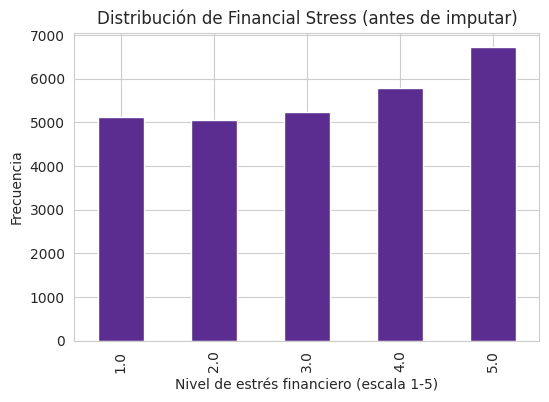

count    27898.000000
mean         3.139867
std          1.437347
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Financial Stress, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
df_clean['Financial Stress'].value_counts().sort_index().plot(kind='bar', color='#5C2D91')
plt.title('Distribución de Financial Stress (antes de imputar)')
plt.xlabel('Nivel de estrés financiero (escala 1-5)')
plt.ylabel('Frecuencia')
plt.show()

print(df_clean['Financial Stress'].describe())


**Decisión:** `Financial Stress` es una variable **ordinal discreta** (1 a 5), no continua.
Usamos la **moda** (valor más frecuente) para imputar, en lugar de la media o incluso la mediana,
porque preserva un valor real y observado de la escala, sin introducir decimales sin sentido en
una variable categórica ordinal.

**Supuesto que asumimos:** que los valores faltantes son aleatorios (MCAR) y no están
sistemáticamente relacionados con el nivel real de estrés financiero del estudiante. El porcentaje
de faltantes es marginal, por lo que el impacto de esta decisión sobre el modelo final es mínimo,
pero se documenta igual por trazabilidad.

In [ ]:
moda_financial_stress = df_clean['Financial Stress'].mode()[0]
n_nulos_antes = df_clean['Financial Stress'].isna().sum()

df_clean['Financial Stress'] = df_clean['Financial Stress'].fillna(moda_financial_stress)

print(f"Valor usado para imputar (moda): {moda_financial_stress}")
print(f"Registros imputados: {n_nulos_antes}")
print(f"Valores nulos restantes: {df_clean['Financial Stress'].isna().sum()}")


Valor usado para imputar (moda): 5.0
Registros imputados: 3
Valores nulos restantes: 0


### 4.3 Codificación de variables ordinales

**Punto crítico (transformación silenciosa):** codificar una variable ordinal con un
`LabelEncoder` automático puede asignar números en orden alfabético, no en el orden real de la
escala, imponiendo una distancia artificial e incorrecta entre categorías. Por eso mapeamos
`Sleep Duration` de forma **explícita y manual**.

**Supuesto que asumimos:** que el orden que definimos abajo (de menos a más horas de sueño)
refleja fielmente la progresión real de la variable.

In [ ]:
orden_sueno = {
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3,
    'More than 8 hours': 4,
}
df_clean['Sleep_Duration_ordinal'] = df_clean['Sleep Duration'].map(orden_sueno)

no_mapeados = df_clean[df_clean['Sleep_Duration_ordinal'].isna()]['Sleep Duration'].unique()
print(f"Categorías de Sleep Duration NO contempladas en el mapeo inicial: {no_mapeados}")


Categorías de Sleep Duration NO contempladas en el mapeo inicial: ['Others']


**Hallazgo inesperado:** el mapeo inicial deja valores nulos — existe una categoría
adicional, `"Others"`, que no se detectó en la auditoría de consistencia de la Sección 2.2 porque
en ese momento revisamos solo las categorías más frecuentes. Esto confirma por qué la validación
posterior a cada transformación es indispensable, no un trámite.

**Decisión:** `"Others"` es una categoría ambigua que no se puede ubicar de forma confiable en la
escala ordinal (no sabemos si representa menos o más horas que las categorías conocidas). Se
imputa con la **moda** de la variable ordinal ya mapeada, igual que se hizo con `Financial Stress`,
manteniendo la variable utilizable sin inventar un valor arbitrario en un extremo de la escala.

**Supuesto que asumimos:** que la distribución de horas de sueño de los estudiantes que
respondieron "Others" no difiere sistemáticamente del resto — es una limitación conocida y
documentada, no una certeza.

In [ ]:
moda_sleep_ordinal = df_clean['Sleep_Duration_ordinal'].mode()[0]
n_others = df_clean['Sleep_Duration_ordinal'].isna().sum()

df_clean['Sleep_Duration_ordinal'] = df_clean['Sleep_Duration_ordinal'].fillna(moda_sleep_ordinal)

print(f"Registros con categoría 'Others' imputados con la moda ({moda_sleep_ordinal}): {n_others}")
print(f"Valores nulos restantes en Sleep_Duration_ordinal: {df_clean['Sleep_Duration_ordinal'].isna().sum()}")

df_clean[['Sleep Duration', 'Sleep_Duration_ordinal']].drop_duplicates()


Registros con categoría 'Others' imputados con la moda (1.0): 18
Valores nulos restantes en Sleep_Duration_ordinal: 0


,Sleep Duration,Sleep_Duration_ordinal
0,5-6 hours,2.0
2,Less than 5 hours,1.0
3,7-8 hours,3.0
15,More than 8 hours,4.0
1963,Others,1.0


### 4.4 Codificación de variables binarias

Se mapean explícitamente (no con `get_dummies` automático) para tener control total sobre qué
valor representa qué categoría, y evitar ambigüedad al interpretar los resultados del modelo
más adelante.

In [ ]:
df_clean['Suicidal_thoughts_bin'] = df_clean['Have you ever had suicidal thoughts ?'].map({'Yes': 1, 'No': 0})
df_clean['Family_History_bin'] = df_clean['Family History of Mental Illness'].map({'Yes': 1, 'No': 0})
df_clean['Gender_bin'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})

# Validación: que no queden nulos por categorías inesperadas (p. ej. "Other" en Gender)
for col in ['Suicidal_thoughts_bin', 'Family_History_bin', 'Gender_bin']:
    n_nulos = df_clean[col].isna().sum()
    print(f"{col}: {n_nulos} valores nulos tras el mapeo")


Suicidal_thoughts_bin: 0 valores nulos tras el mapeo
Family_History_bin: 0 valores nulos tras el mapeo
Gender_bin: 0 valores nulos tras el mapeo


### 4.5 Tratamiento de variables de alta cardinalidad: `City` y `Degree`

**Decisión:** en lugar de crear decenas de columnas dummy (lo que generaría un dataset muy disperso
y propenso a sobreajuste), aplicamos **codificación por frecuencia**: cada categoría se reemplaza
por la proporción de registros que representa. Esto conserva información sobre qué tan común es
cada ciudad/programa sin explotar la dimensionalidad.

**Supuesto que asumimos:** que la frecuencia de aparición de una ciudad o programa es, por sí
misma, una señal razonable (aunque imperfecta) — esta es una decisión que se puede revisar en la
fase de modelado si el desempeño no es satisfactorio.

In [ ]:
frecuencia_city = df_clean['City'].value_counts(normalize=True)
frecuencia_degree = df_clean['Degree'].value_counts(normalize=True)

df_clean['City_freq'] = df_clean['City'].map(frecuencia_city)
df_clean['Degree_freq'] = df_clean['Degree'].map(frecuencia_degree)

df_clean[['City', 'City_freq', 'Degree', 'Degree_freq']].head()


,City,City_freq,Degree,Degree_freq
0,Visakhapatnam,0.034730,B.Pharm,0.029031
1,Bangalore,0.027490,BSc,0.031827
2,Srinagar,0.049174,BA,0.021505
3,Varanasi,0.024551,BCA,0.051360
4,Jaipur,0.037131,M.Tech,0.036630


### 4.6 Decisión documentada sobre outliers

Con base en la Sección 3.3, los outliers detectados en `Age`, `CGPA` y `Work/Study Hours`
representan un porcentaje bajo del dataset y son valores plausibles dentro del contexto
universitario (por ejemplo, estudiantes de posgrado de mayor edad). **Decisión: no se eliminan**,
para no perder información real y potencialmente relevante para el riesgo de depresión (un
estudiante con carga horaria extrema es, precisamente, un caso de interés para el proyecto).


### 4.7 Decisión documentada sobre `Profession`

Confirmado en la Sección 2.3: 99%+ de los registros son "Student", variable con varianza casi
nula. **Decisión:** se conserva en `df_clean` por trazabilidad, pero se marca explícitamente como
**no recomendada para el modelo** — la exclusión final se ejecuta en el notebook de modelado, no
aquí, para que la decisión quede documentada y sea reversible si el equipo cambia de criterio.


### 4.8 Normalización de variables numéricas continuas

**Punto crítico:** normalizamos *después* de haber revisado los outliers (Sección 3.3), nunca
antes — normalizar antes de detectar outliers puede enmascararlos, haciendo que dejen de parecer
atípicos y perdiendo la oportunidad de decidir conscientemente qué hacer con ellos.

In [ ]:
from sklearn.preprocessing import StandardScaler

variables_a_normalizar = ['Age', 'CGPA', 'Work/Study Hours', 'Academic Pressure',
                           'Financial Stress', 'Study Satisfaction']

scaler = StandardScaler()
columnas_normalizadas = [c + '_norm' for c in variables_a_normalizar]
df_clean[columnas_normalizadas] = scaler.fit_transform(df_clean[variables_a_normalizar])

df_clean[variables_a_normalizar + columnas_normalizadas].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,27901.0,2.582230e+01,4.905687,18.000000,21.000000,25.000000,30.000000,59.000000
CGPA,27901.0,7.656104e+00,1.470707,0.000000,6.290000,7.770000,8.920000,10.000000
Work/Study Hours,27901.0,7.156984e+00,3.707642,0.000000,4.000000,8.000000,10.000000,12.000000
Academic Pressure,27901.0,3.141214e+00,1.381465,0.000000,2.000000,3.000000,4.000000,5.000000
Financial Stress,27901.0,3.140067e+00,1.437399,1.000000,2.000000,3.000000,4.000000,5.000000
Study Satisfaction,27901.0,2.943837e+00,1.361148,0.000000,2.000000,3.000000,4.000000,5.000000
Age_norm,27901.0,1.739367e-16,1.000018,-1.594566,-0.983020,-0.167625,0.851619,6.763230
CGPA_norm,27901.0,4.008438e-16,1.000018,-5.205822,-0.928892,0.077444,0.859395,1.593749
Work/Study Hours_norm,27901.0,4.876848e-17,1.000018,-1.930368,-0.851495,0.227377,0.766813,1.306249
Academic Pressure_norm,27901.0,1.871793e-17,1.000018,-2.273869,-0.826104,-0.102222,0.621660,1.345543


### 4.9 Validación final post-limpieza

In [ ]:
print("=== VALIDACIÓN POST-LIMPIEZA ===\n")
print(f"Shape final: {df_clean.shape}")
print(f"Filas originales: {df.shape[0]} | Filas tras limpieza: {df_clean.shape[0]}")
print(f"\nValores nulos restantes por columna (debe ser 0 en las que tratamos):")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
if df_clean.isna().sum().sum() == 0:
    print("✔ No quedan valores nulos en ninguna columna.")

print(f"\nDuplicados restantes: {df_clean.duplicated().sum()}")


=== VALIDACIÓN POST-LIMPIEZA ===

Shape final: (27901, 30)
Filas originales: 27901 | Filas tras limpieza: 27901

Valores nulos restantes por columna (debe ser 0 en las que tratamos):
Series([], dtype: int64)
✔ No quedan valores nulos en ninguna columna.

Duplicados restantes: 0


## 5. Auditoría preliminar de sesgo

Esta sección es insumo directo para la **Bitácora de Error #2**, que exige explícitamente
revisar si hay subrepresentación de grupos poblacionales o sesgos de muestreo/reporte.


### 5.1 Representación por género

Gender
Male      55.7
Female    44.3
Name: proportion, dtype: float64


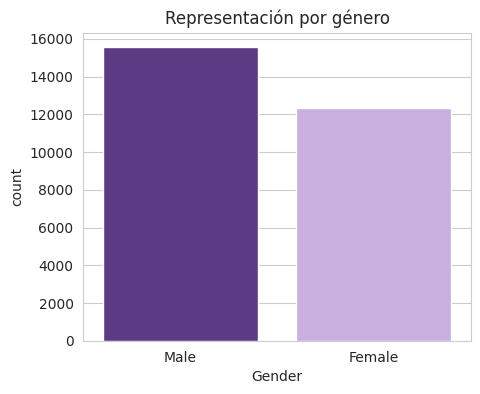

In [ ]:
print(df_clean['Gender'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x='Gender', data=df_clean, hue='Gender', palette=['#5C2D91', '#C9A6E8'], legend=False)
plt.title('Representación por género')
plt.show()


### 5.2 Representación geográfica y de origen del dataset

In [ ]:
print(f"Todas las ciudades del dataset corresponden a India: {df_clean['City'].nunique()} ciudades distintas.")
print("Top 5 ciudades más representadas:")
print(df_clean['City'].value_counts(normalize=True).head(5).round(3) * 100)


Todas las ciudades del dataset corresponden a India: 52 ciudades distintas.
Top 5 ciudades más representadas:
City
Kalyan         5.6
Srinagar       4.9
Hyderabad      4.8
Vasai-Virar    4.6
Lucknow        4.1
Name: proportion, dtype: float64


**Riesgo de sesgo identificado:** el dataset no incluye ningún estudiante colombiano o
latinoamericano. Cualquier patrón encontrado refleja el contexto sociocultural de India
(sistema educativo, normas culturales sobre salud mental, presión familiar, etc.), que puede
diferir sustancialmente del contexto colombiano. **Mitigación:** los resultados se contrastarán
con la ENSM antes de cualquier recomendación operativa para Bienestar Universitario (documentado
en el Entregable 1).

### 5.3 Representación por rango de edad

Age_group
20-25    30.7
26-30    28.1
30+      21.9
<20      19.3
Name: proportion, dtype: float64


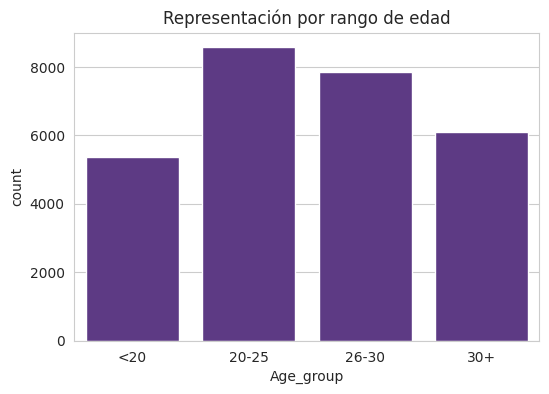

In [ ]:
df_clean['Age_group'] = pd.cut(df_clean['Age'], bins=[0, 20, 25, 30, 100],
                                labels=['<20', '20-25', '26-30', '30+'])
print(df_clean['Age_group'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='Age_group', data=df_clean, order=['<20','20-25','26-30','30+'],
              color='#5C2D91')
plt.title('Representación por rango de edad')
plt.show()


### 5.4 Tasa de la variable objetivo por subgrupos (chequeo de equidad)

In [ ]:
print("Tasa de Depression=1 por género:")
print(df_clean.groupby('Gender')['Depression'].mean().round(3) * 100)

print("\nTasa de Depression=1 por rango de edad:")
print(df_clean.groupby('Age_group', observed=True)['Depression'].mean().round(3) * 100)


Tasa de Depression=1 por género:
Gender
Female    58.5
Male      58.6
Name: Depression, dtype: float64

Tasa de Depression=1 por rango de edad:
Age_group
<20      72.3
20-25    64.3
26-30    56.5
30+      40.9
Name: Depression, dtype: float64


**Hallazgo:** se documentan las tasas de depresión por subgrupo aquí para que, en la fase
de validación del modelo, el equipo pueda comparar si el modelo predice con precisión similar
en cada subgrupo (evaluación de equidad), y no solo si acierta en promedio.

## 6. Guardar el dataset procesado y control de versiones (Paso 3)

In [ ]:
ruta_salida = Path('../data/processed/student_depression_clean.csv')
ruta_salida.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(ruta_salida, index=False)
print(f"Dataset procesado guardado en: {ruta_salida.resolve()}")
print(f"Shape final guardado: {df_clean.shape}")


Dataset procesado guardado en: /data/processed/student_depression_clean.csv
Shape final guardado: (27901, 31)


In [ ]:
from google.colab import files

ruta_salida = '../data/processed/student_depression_clean.csv'

files.download(ruta_salida)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Resumen ejecutivo (para la revisión del docente y la Bitácora de Error #2)

### Decisiones tomadas y su justificación

| # | Decisión | Justificación | Riesgo si se hacía mal |
|---|---|---|---|
| 1 | Eliminar duplicados exactos | Un duplicado exacto es un error de carga, no una coincidencia real | Inflar artificialmente el tamaño de una clase |
| 2 | Imputar `Financial Stress` con la moda, no la media | Variable ordinal discreta; la media no es interpretable en esa escala | Introducir un valor de estrés que no existe en la escala real (transformación silenciosa) |
| 3 | Mapeo manual y explícito de `Sleep Duration`, con imputación por moda para la categoría ambigua `"Others"` (18 registros) | Evitar que un encoder automático imponga un orden alfabético incorrecto; `"Others"` no es ubicable de forma confiable en la escala | Distorsionar por completo la relación entre sueño y riesgo, o perder 18 registros sin justificación |
| 4 | Codificación por frecuencia en `City`/`Degree` | Evitar explosión dimensional de variables dummy con decenas de categorías | Sobreajuste del modelo a categorías poco representadas |
| 5 | Normalizar después de revisar outliers, no antes | Evitar enmascarar valores atípicos relevantes | Ocultar exactamente los casos extremos de mayor interés para el proyecto |
| 6 | No eliminar `Profession` todavía | Mantener trazabilidad de por qué se descarta una variable | Perder el registro de la decisión y su justificación |
| 7 | No eliminar outliers de `Age`/`CGPA`/`Work-Study Hours` | Son valores plausibles y potencialmente informativos, no errores de captura | Perder casos reales de alto interés (ej. sobrecarga extrema de horas) |

### Riesgos de sesgo identificados

- El dataset es 100% de estudiantes de **India** — sin representación colombiana o latinoamericana.
- `City` y `Degree` tienen alta cardinalidad con posible subrepresentación de ciertas categorías.
- La variable `Have you ever had suicidal thoughts ?` es de altísimo poder predictivo pero
  extremadamente sensible — su uso debe ir acompañado de las salvaguardas éticas descritas en el
  Entregable 1 (anonimización, uso agregado, comunicación exclusiva a personal autorizado).
